 Successfully loaded data with shape: (48144, 5)
 Columns: ['valid_time', 't2m', 'latitude', 'longitude', 'tp']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48144 entries, 0 to 48143
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   valid_time  48144 non-null  datetime64[ns]
 1   t2m         48144 non-null  float64       
 2   latitude    48144 non-null  float64       
 3   longitude   48144 non-null  float64       
 4   tp          48144 non-null  float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 1.8 MB


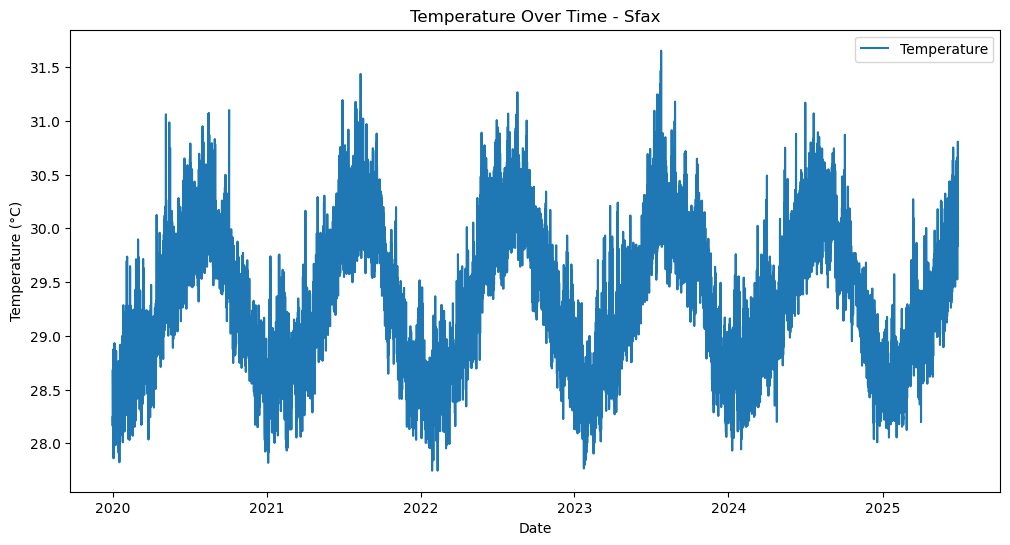

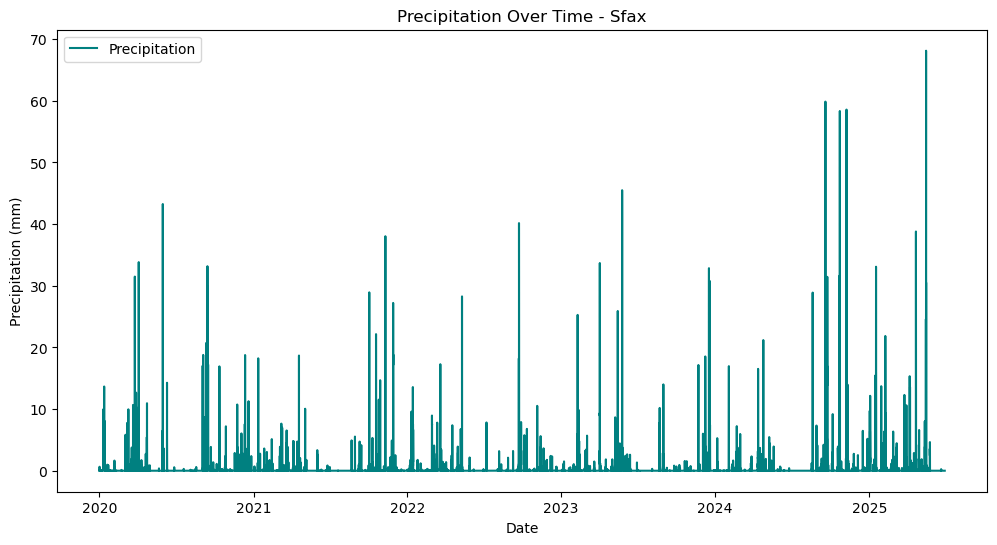

valid_time    0
t2m           0
latitude      0
longitude     0
tp            0
dtype: int64
Found 0 duplicate rows.
valid_time    0
t2m           0
latitude      0
longitude     0
tp            0
dtype: int64
                          valid_time           t2m      latitude  \
count                          48144  48144.000000  4.814400e+04   
mean   2022-09-29 23:29:59.999999744     29.338977  3.490000e+01   
min              2020-01-01 00:00:00     27.745710  3.490000e+01   
25%              2021-05-16 11:45:00     28.807956  3.490000e+01   
50%              2022-09-29 23:30:00     29.309009  3.490000e+01   
75%              2024-02-13 11:15:00     29.844176  3.490000e+01   
max              2025-06-28 23:00:00     31.652612  3.490000e+01   
std                              NaN      0.659409  2.580718e-11   

          longitude            tp  
count  4.814400e+04  48144.000000  
mean   1.080000e+01      0.206812  
min    1.080000e+01     -0.000353  
25%    1.080000e+01      0.000000

,valid_time,t2m,latitude,longitude,tp
0,2020-01-01 00:00:00,28.243674,34.9,10.8,0.0
1,2020-01-01 01:00:00,28.215353,34.9,10.8,0.0
2,2020-01-01 02:00:00,28.201242,34.9,10.8,0.0
3,2020-01-01 03:00:00,28.185904,34.9,10.8,0.0
4,2020-01-01 04:00:00,28.185730,34.9,10.8,0.0


(48144, 5)


,valid_time,t2m,latitude,longitude,tp
48139,2025-06-28 19:00:00,30.241364,34.9,10.8,-0.000060
48140,2025-06-28 20:00:00,30.150800,34.9,10.8,-0.000060
48141,2025-06-28 21:00:00,30.087177,34.9,10.8,0.000089
48142,2025-06-28 22:00:00,30.036290,34.9,10.8,-0.000060
48143,2025-06-28 23:00:00,29.987268,34.9,10.8,0.000151


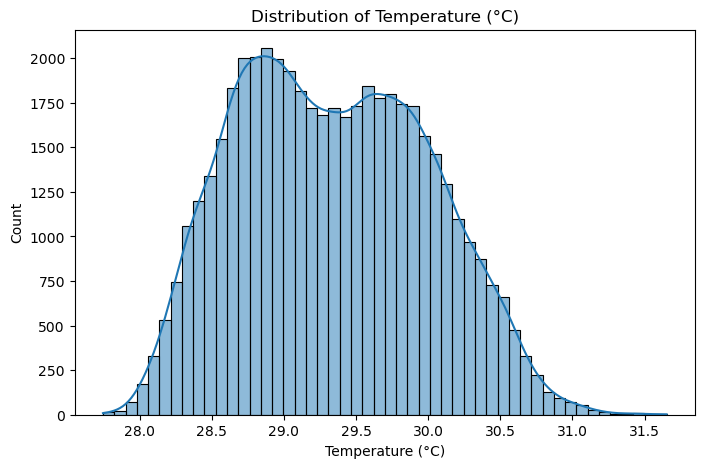

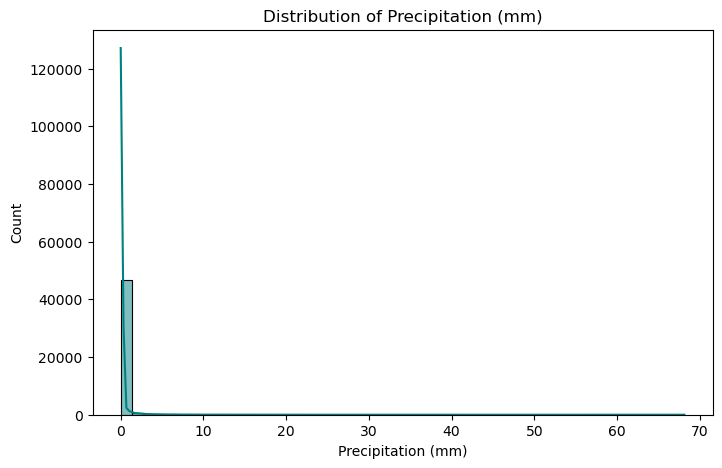

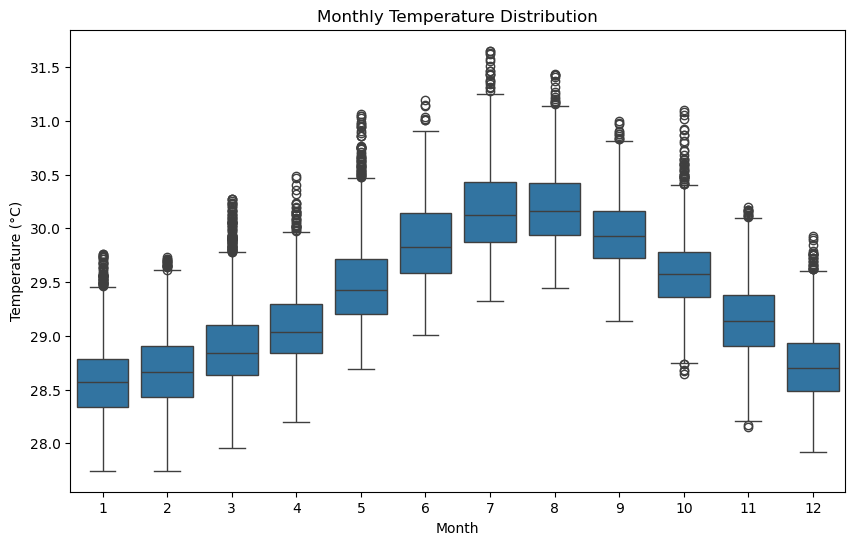

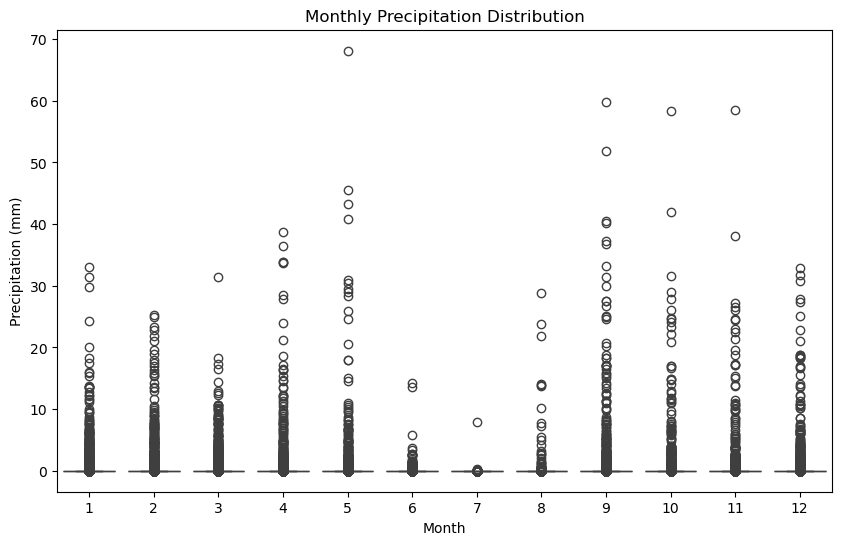

In [13]:
import sys
import os
sys.path.append(os.path.abspath("../src"))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from data_ingestion import load_weather_data

file_path = "C:/Users/MSI/MLops-Project-1/data/raw/Sfax.csv"
df = load_weather_data(file_path)

df.head()
df.info()
df.describe()

if 'valid_time' in df.columns:
    df['t2m'] = df['t2m'] / 10
    df['tp'] = df['tp'] * 10000
    plt.figure(figsize=(12,6))
    plt.plot(df['valid_time'], df['t2m'], label='Temperature')
    plt.xlabel('Date')
    plt.ylabel('Temperature (°C)')
    plt.title('Temperature Over Time - Sfax')
    plt.legend()
    plt.show()

    plt.figure(figsize=(12,6))
    plt.plot(df['valid_time'], df['tp'], label='Precipitation', color='teal')
    plt.xlabel('Date')
    plt.ylabel('Precipitation (mm)')
    plt.title('Precipitation Over Time - Sfax')
    plt.legend()
    plt.show()
df['valid_time'] = pd.to_datetime(df['valid_time'], errors='coerce')

print(df.isnull().sum())

df = df.dropna(subset=['valid_time'])

duplicates = df.duplicated().sum()
print(f"Found {duplicates} duplicate rows.")
df = df.drop_duplicates()

print(df.isnull().sum())

df = df.dropna()

print(df.describe())

df = df[(df['t2m'] > -10) & (df['t2m'] < 55)]

df = df.sort_values('valid_time').reset_index(drop=True)

cleaned_path = "../data/processed/sfax_weather_cleaned.csv"
df.to_csv(cleaned_path, index=False)
print(f"Cleaned data saved to {cleaned_path}")

display(df.head())
print(df.shape)

display(df.tail())


plt.figure(figsize=(8, 5))
sns.histplot(df['t2m'], bins=50, kde=True)
plt.title('Distribution of Temperature (°C)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df['tp'], bins=50, kde=True, color='teal')
plt.title('Distribution of Precipitation (mm)')
plt.xlabel('Precipitation (mm)')
plt.ylabel('Count')
plt.show()

df['month'] = df['valid_time'].dt.month

plt.figure(figsize=(10, 6))
sns.boxplot(x='month', y='t2m', data=df)
plt.title('Monthly Temperature Distribution')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='month', y='tp', data=df)
plt.title('Monthly Precipitation Distribution')
plt.xlabel('Month')
plt.ylabel('Precipitation (mm)')
plt.show()


